# Exploratory Data Analysis

   ## Project Overview
   This solo project aims to analyze the biggest factors when it comes to increasing the chance of winning a League of Legends ranked game.

In [1]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv('data/games.csv')

# Basic data info
print(f"Dataset shape: {df.shape}")
print(f"Column names: {df.columns.to_list()}")
df.head()

Dataset shape: (51490, 61)
Column names: ['gameId', 'creationTime', 'gameDuration', 'seasonId', 'winner', 'firstBlood', 'firstTower', 'firstInhibitor', 'firstBaron', 'firstDragon', 'firstRiftHerald', 't1_champ1id', 't1_champ1_sum1', 't1_champ1_sum2', 't1_champ2id', 't1_champ2_sum1', 't1_champ2_sum2', 't1_champ3id', 't1_champ3_sum1', 't1_champ3_sum2', 't1_champ4id', 't1_champ4_sum1', 't1_champ4_sum2', 't1_champ5id', 't1_champ5_sum1', 't1_champ5_sum2', 't1_towerKills', 't1_inhibitorKills', 't1_baronKills', 't1_dragonKills', 't1_riftHeraldKills', 't1_ban1', 't1_ban2', 't1_ban3', 't1_ban4', 't1_ban5', 't2_champ1id', 't2_champ1_sum1', 't2_champ1_sum2', 't2_champ2id', 't2_champ2_sum1', 't2_champ2_sum2', 't2_champ3id', 't2_champ3_sum1', 't2_champ3_sum2', 't2_champ4id', 't2_champ4_sum1', 't2_champ4_sum2', 't2_champ5id', 't2_champ5_sum1', 't2_champ5_sum2', 't2_towerKills', 't2_inhibitorKills', 't2_baronKills', 't2_dragonKills', 't2_riftHeraldKills', 't2_ban1', 't2_ban2', 't2_ban3', 't2_ban4', '

,gameId,creationTime,gameDuration,seasonId,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
0,3326086514,1504279457970,1949,9,1,2,1,1,1,1,...,5,0,0,1,1,114,67,43,16,51
1,3229566029,1497848803862,1851,9,1,1,1,1,0,1,...,2,0,0,0,0,11,67,238,51,420
2,3327363504,1504360103310,1493,9,1,2,1,1,1,2,...,2,0,0,1,0,157,238,121,57,28
3,3326856598,1504348503996,1758,9,1,1,1,1,1,1,...,0,0,0,0,0,164,18,141,40,51
4,3330080762,1504554410899,2094,9,1,2,1,1,1,1,...,3,0,0,1,0,86,11,201,122,18


In [2]:
print("Basic description of all of the features:")

# We store the creation time for later maybe
creation_time_col = df['creationTime']
df = df.drop(['gameId', 'creationTime', 'seasonId'], axis=1)

# Detecting any null values in features
null_counts = df.isna().sum()
if (null_counts == 0).all():
    print("- No null values found in any feature.")
else:
    print(f"- Features with null values:\n{null_counts[null_counts > 0]}")
    
# Checking data types
print(f"- Unique data types in the dataset: {(df.dtypes.unique())}")

df.describe()

Basic description of all of the features:
- No null values found in any feature.
- Unique data types in the dataset: [dtype('int64')]


,gameDuration,winner,firstBlood,firstTower,firstInhibitor,firstBaron,firstDragon,firstRiftHerald,t1_champ1id,t1_champ1_sum1,...,t2_towerKills,t2_inhibitorKills,t2_baronKills,t2_dragonKills,t2_riftHeraldKills,t2_ban1,t2_ban2,t2_ban3,t2_ban4,t2_ban5
count,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,...,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000,51490.000000
mean,1832.362808,1.493552,1.471295,1.450631,1.308487,0.926510,1.442804,0.731676,114.293397,6.601787,...,5.549466,0.985084,0.414547,1.404370,0.240105,108.216294,107.910216,108.690581,108.626044,108.066576
std,512.017696,0.499963,0.520326,0.542848,0.676097,0.841424,0.569579,0.822526,119.000867,4.025601,...,3.860989,1.256284,0.613768,1.224492,0.427151,102.551787,102.870710,102.592145,103.346952,102.756149
min,190.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1531.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,35.000000,4.000000,...,2.000000,0.000000,0.000000,0.000000,0.000000,38.000000,37.000000,38.000000,38.000000,38.000000
50%,1833.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,79.000000,4.000000,...,6.000000,0.000000,0.000000,1.000000,0.000000,90.000000,90.000000,90.000000,90.000000,90.000000
75%,2148.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,136.000000,11.000000,...,9.000000,2.000000,1.000000,2.000000,0.000000,141.000000,141.000000,141.000000,141.000000,141.000000
max,4728.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,516.000000,21.000000,...,11.000000,10.000000,4.000000,6.000000,1.000000,516.000000,516.000000,516.000000,516.000000,516.000000


We saw that the dataset includes only one datatype int64 and contains no null values.

Now we generate histogram plots for the continuous features to show the distribution of them.

I will not plot features with 'first' in their name because their values only indicate which team got the objective.

I also dropped champion picks/bans and summoner spell picks since their values are the champions IDs and not some ingame feature.

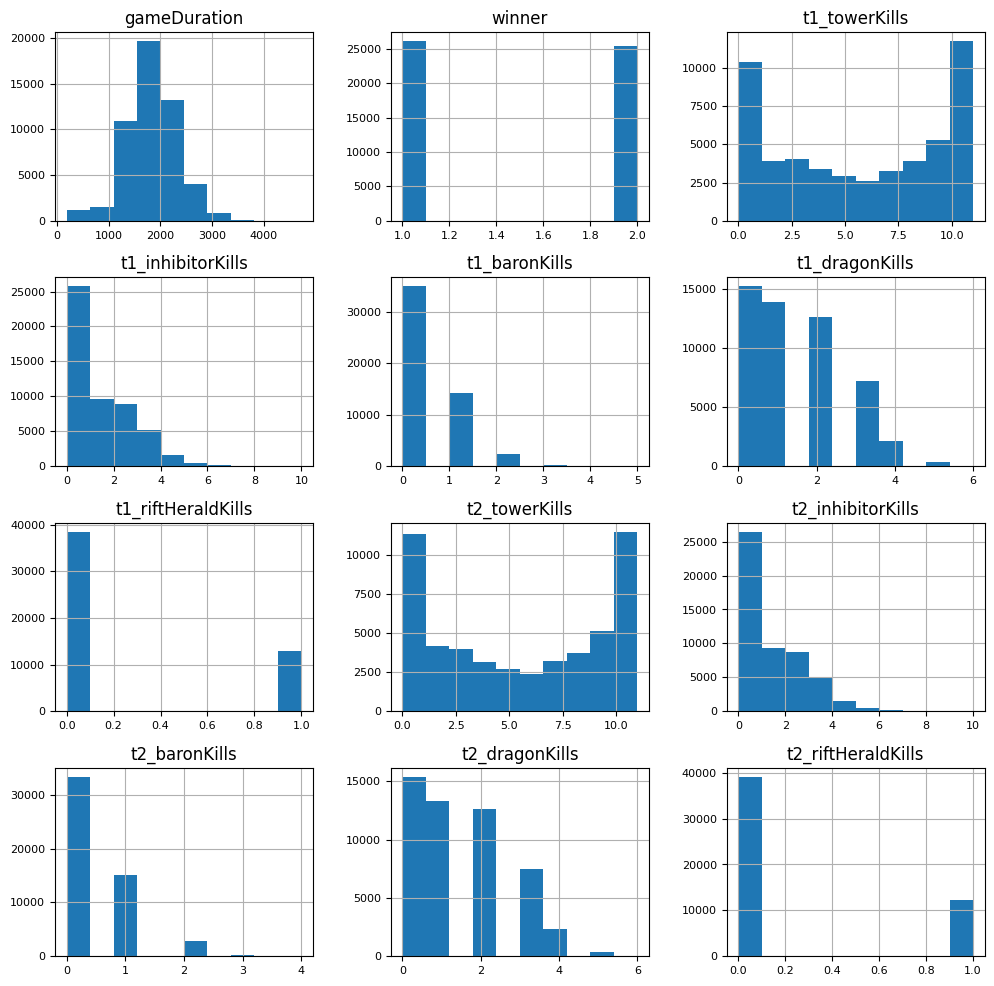

In [3]:

# Generating the list of columns to drop
cols_to_drop = []

for team in [1, 2]:
    for i in range(1, 6):
        cols_to_drop.append(f't{team}_champ{i}id')
        cols_to_drop.append(f't{team}_ban{i}')
        for sum in [1, 2]:
            cols_to_drop.append(f't{team}_champ{i}_sum{sum}')

# Store first event columns for evaluation later
events = ['Blood', 'Tower', 'Inhibitor', 'Baron', 'Dragon', 'RiftHerald']
first_events_cols = [f'first{event}' for event in events]

hist_df = df.drop(cols_to_drop, axis=1)
hist_df = hist_df.drop(first_events_cols, axis=1)

# continuous_features = hist_df.nunique()[df.nunique() > 3]
# hist_df = hist_df[continuous_features.index.tolist()]
hist_df.hist(figsize=(12, 12), xlabelsize=8, ylabelsize=8);


Lets examine the correlation between the features and the target.
Here we are checking the correlation between continuous numerical features against a binary target (victory or loss), this can be done by using a violin plot or a box plot.

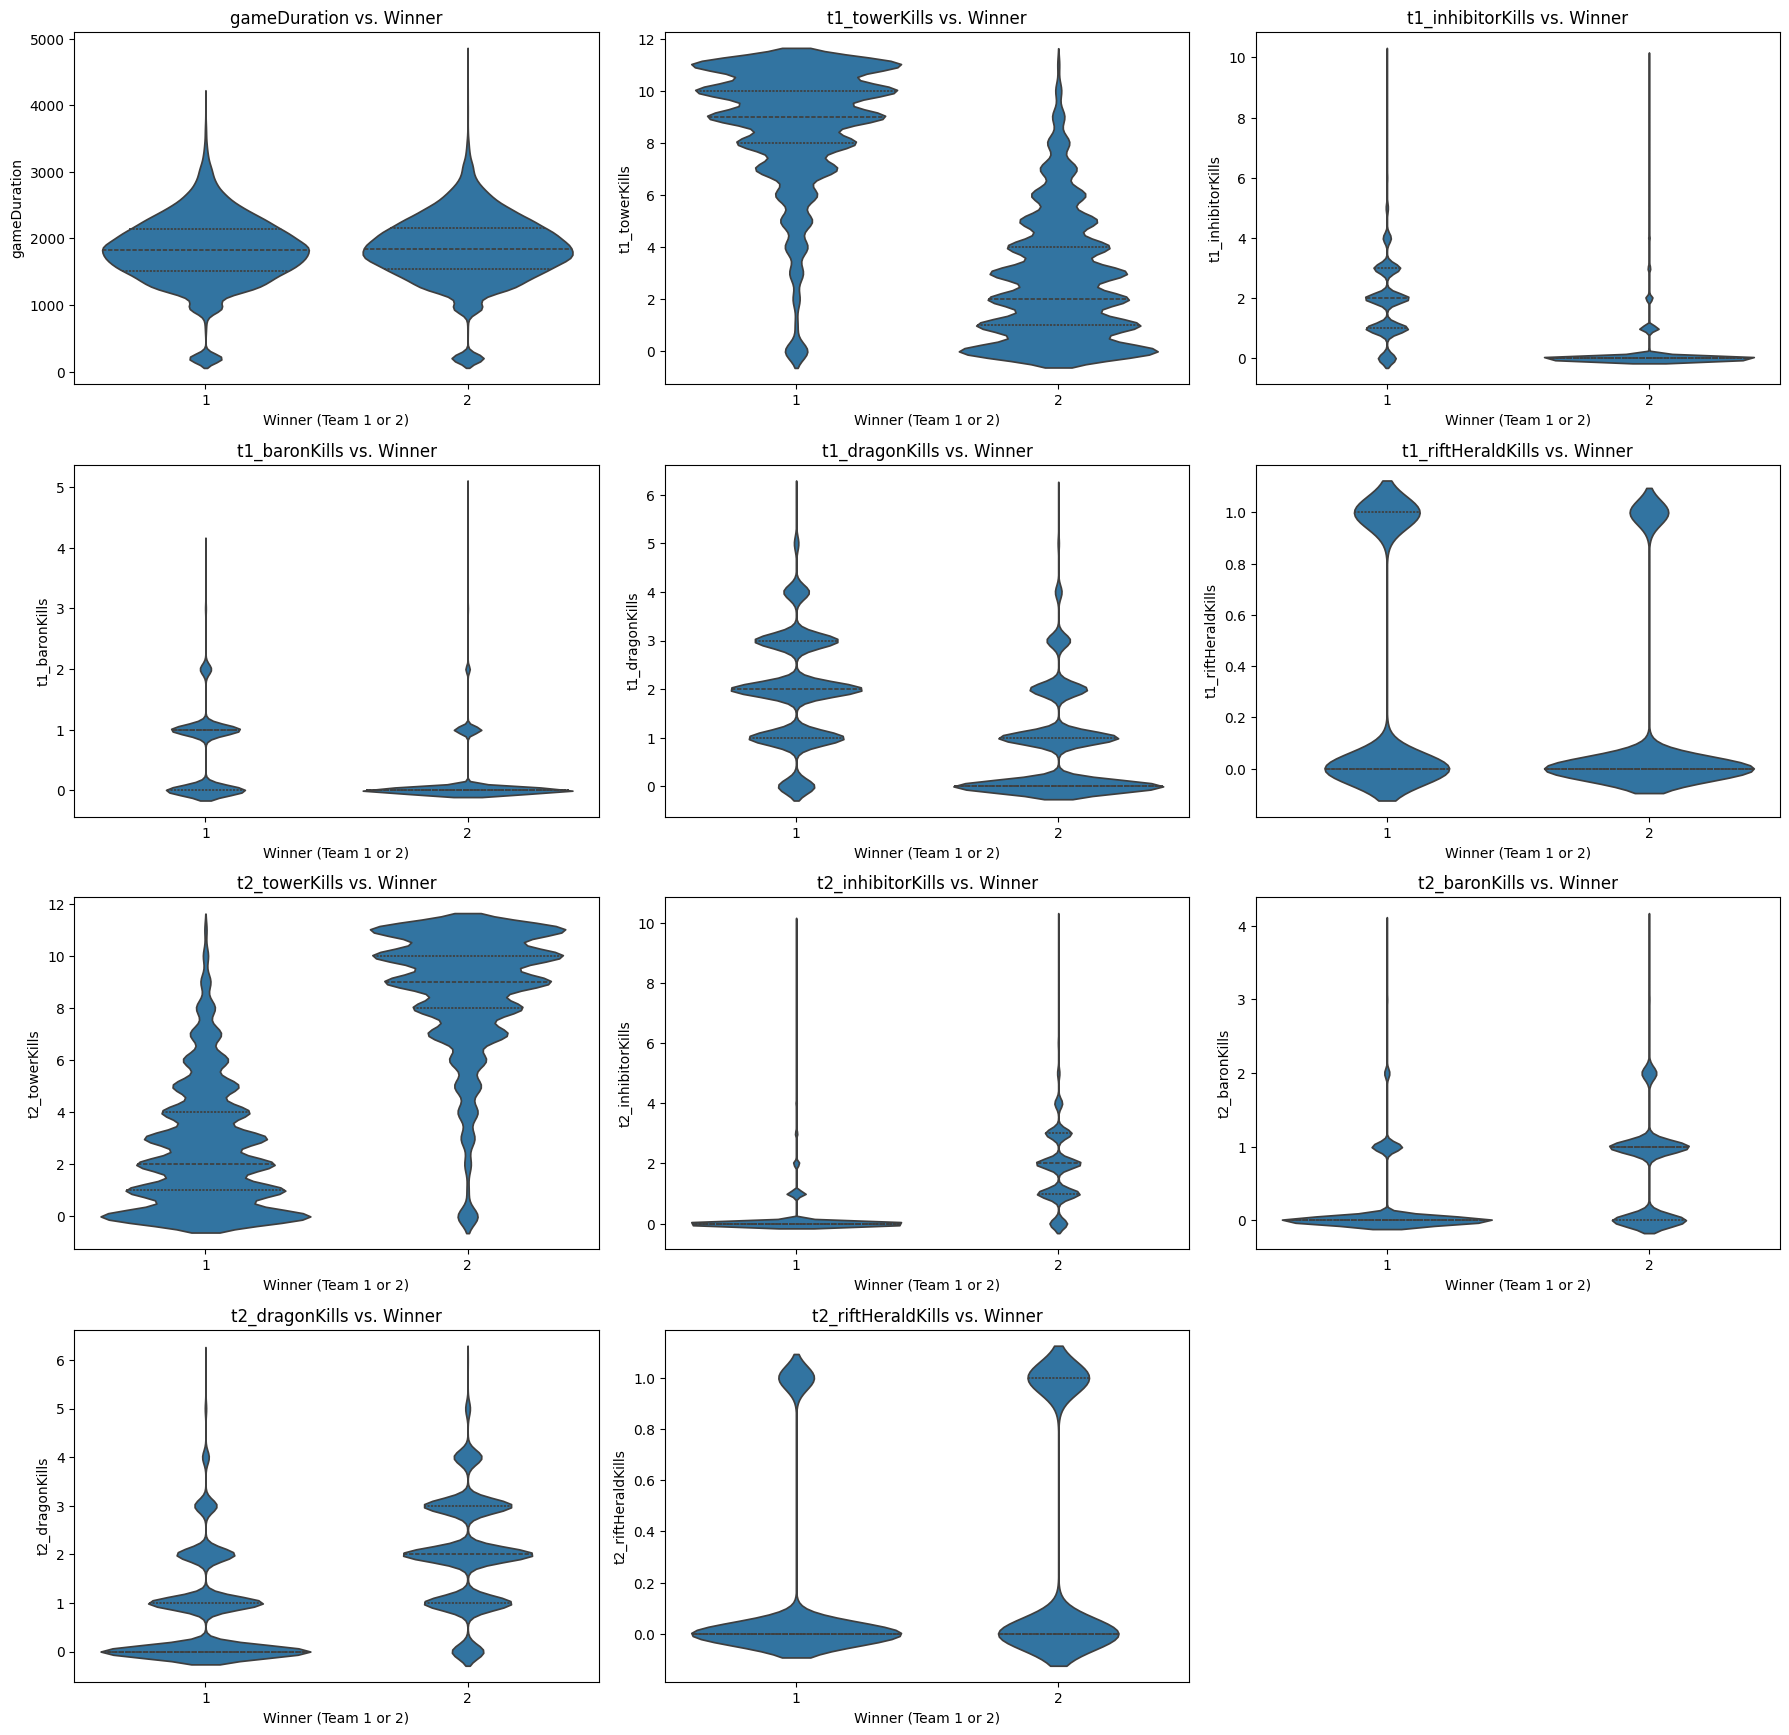

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pick the features excluding the target
target = hist_df['winner']
cols_to_plot = [col for col in hist_df.columns if col != 'winner']
num_of_features = len(cols_to_plot)

# Create the subplots
fig, ax = plt.subplots(nrows=(2 * num_of_features) // 3, ncols=3, figsize=(18, 30))
ax = ax.flatten()

for i, feature in enumerate(cols_to_plot):
    sns.violinplot(x='winner', y=feature, data=hist_df, ax=ax[i], inner='quartile')
    ax[i].set_title(f'{feature} vs. Winner')
    ax[i].set_xlabel('Winner (Team 1 or 2)')
    ax[i].set_ylabel(feature)
    
# Delete leftover subplots if there are any
for j in range(num_of_features, len(ax)):
    fig.delaxes(ax[j])
    
plt.tight_layout()
plt.show()

It's easy to see some of the most impactful features when it comes to winning like tower kills or dragon kills that shows the increase of won games directly correlated to number of those secured objectives. This makes sense game wise since towers grant the team that takes them gold, space around the map and applies pressure on the enemy team to contest their jungle camps or other objectives like the dragon or baron.

Now we can examine the impact of the first secured objective on the chances of winning the game, this includes first blood, tower, dragon, baron, rift hearld and inhibitor.

In [5]:
# Store the number of wins where a each team has secured one of the first objectives
t1_objectives = {}
t2_objectives = {}

# Calculate the ratios of team1 winning with getting first objective and without
for team in [1, 2]:
    for col in first_events_cols:
        # Store the dataframe where an objective was taken by team
        if team == 1:
            df_not_taken = df[(df[col] == 2) | (df[col] == 0)]
            df_taken = df[df[col] == 1]
        else:
            df_not_taken = df[(df[col] == 1) | (df[col] == 0)]
            df_taken = df[df[col] == 2]
        
        # Calculate and store the conditional win ratios
        win_pct_without = len(df_not_taken[df_not_taken['winner'] == team]) / len(df_not_taken)
        win_pct_with = len(df_taken[df_taken['winner'] == team]) / len(df_taken)
        win_pct_diff = win_pct_with - win_pct_without
        
        # Store in appropriate team's dictionary
        if team == 1:
            t1_objectives[f"t1_{col}"] = [win_pct_without, win_pct_with, win_pct_diff]
        else:
            t2_objectives[f"t2_{col}"] = [win_pct_without, win_pct_with, win_pct_diff]

# Store the column names from the dictionary
t1_event_names = list(t1_objectives.keys())
t2_event_names = list(t2_objectives.keys())

# Creating the dataframes
t1_df = pd.DataFrame(data=t1_objectives, index=['Win % Without', 'Win % With', 'Win % Difference'], columns=t1_event_names)
t2_df = pd.DataFrame(data=t2_objectives, index=['Win % Without', 'Win % With', 'Win % Difference'], columns=t2_event_names)

print("The impact of taking and not taking the first objectives on win probability for team 1:")
display(t1_df)
print("The impact of taking and not taking the first objectives on win probability for team 2:")
display(t2_df)

The impact of taking and not taking the first objectives on win probability for team 1:


,t1_firstBlood,t1_firstTower,t1_firstInhibitor,t1_firstBaron,t1_firstDragon,t1_firstRiftHerald
Win % Without,0.415534,0.302665,0.180335,0.383834,0.341045,0.443257
Win % With,0.594800,0.708403,0.908693,0.811628,0.685986,0.694547
Win % Difference,0.179266,0.405738,0.728358,0.427793,0.344941,0.251291


The impact of taking and not taking the first objectives on win probability for team 2:


,t2_firstBlood,t2_firstTower,t2_firstInhibitor,t2_firstBaron,t2_firstDragon,t2_firstRiftHerald
Win % Without,0.406405,0.300140,0.176304,0.348241,0.325253,0.430010
Win % With,0.587181,0.708019,0.913448,0.802416,0.674677,0.694653
Win % Difference,0.180776,0.407879,0.737144,0.454175,0.349425,0.264643


Lets perform a A/B permutation test where the null hypothesis is that taking the first tower doesn't increase win chance that much and the alternative hypothesis is that it does.

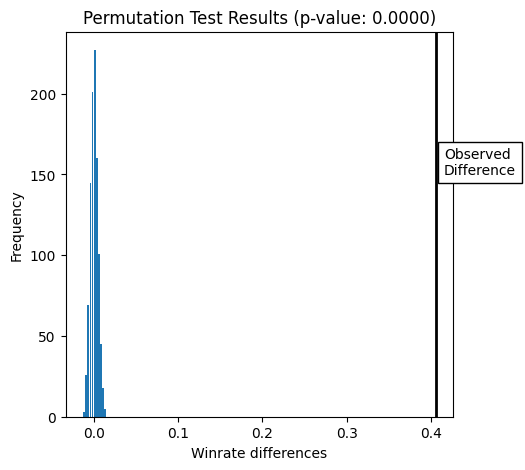

In [16]:
# First lets grab the first tower column
import random


first_tower = df[['firstTower', 'winner']]

# We need to store the length of the groups for the permutation indices in the test
group_A = first_tower[(first_tower['firstTower'] == 0) | (first_tower['firstTower'] == 2)]
group_B = first_tower[(first_tower['firstTower'] == 1)]
len_A = len(group_A)
len_B = len(group_B)

# Lets compute the difference between the winrate of the two groups which will serve as our test statistic
# We can use the calculated winrate from the previous cell for each team
win_diff = t1_df.loc['Win % With', 't1_firstTower'] - t1_df.loc['Win % Without', 't1_firstTower']

# Now we perform the permutation test and plot the winrate differences accross multiple resamples
def perm_fun(x: pd.Series, nA: int, nB: int):
    """
    A permutation function for sampling without replacement.
    """
    n = nA + nB
    idx_B = set(random.sample(range(n), nB))
    idx_A = set(range(n)) - idx_B
    win_A = (x.iloc[list(idx_A)] == 1).sum() / nA
    win_B = (x.iloc[list(idx_B)] == 1).sum() / nB
    return win_A - win_B

perm_diffs = [perm_fun(first_tower['winner'], len_A, len_B) for _ in range(1000)]
fig, ax = plt.subplots(figsize=(5, 5))
ax.hist(perm_diffs, bins=11, rwidth=0.9)
ax.axvline(x=win_diff, color='black', lw=2)
ax.text(win_diff + 0.01, 150, 'Observed\nDifference', bbox={'facecolor':'white'})
ax.set_xlabel('Winrate differences')
ax.set_ylabel('Frequency')

# Now, let's calculate and display the p-value
p_value = np.mean(np.abs(perm_diffs) >= np.abs(win_diff))
ax.set_title(f'Permutation Test Results (p-value: {p_value:.4f})')

plt.show()

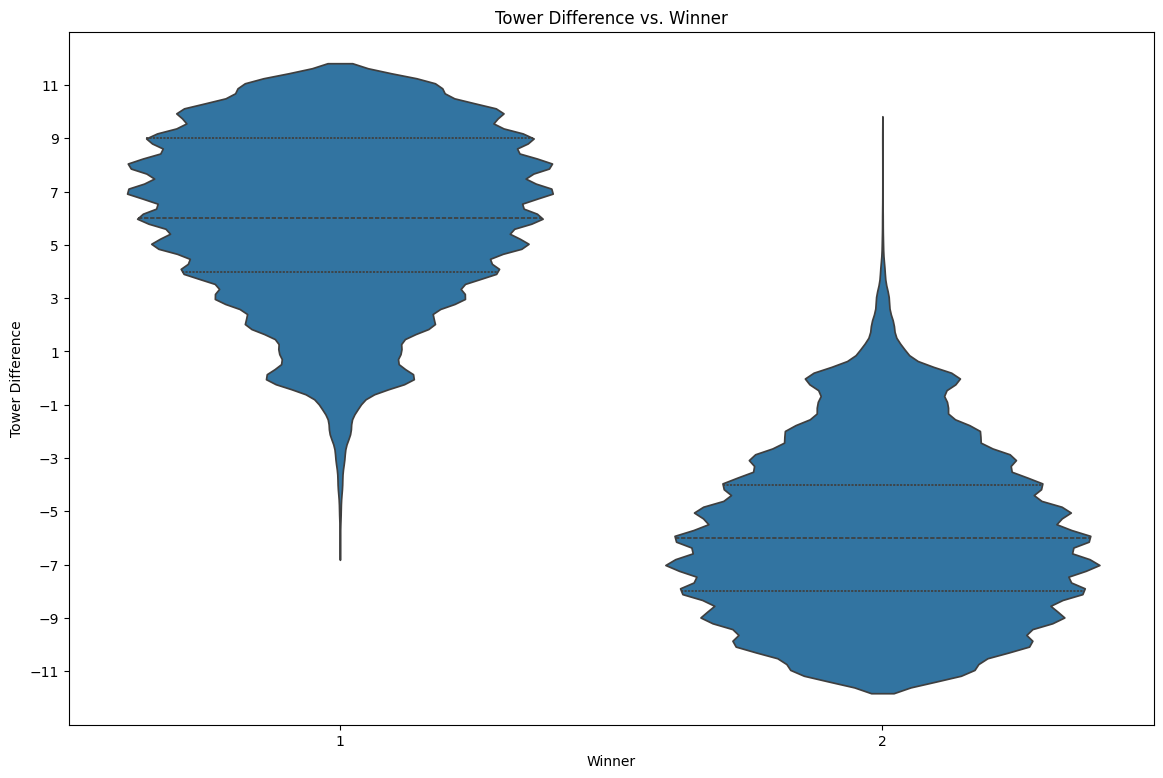

In [ ]:
tower_diff_df = pd.DataFrame(dict(
    tower_diff=df['t1_towerKills']-df['t2_towerKills'],
    winner=df['winner']
))

fig, ax = plt.subplots(figsize=(14, 9))

sns.violinplot(data=tower_diff_df, ax=ax, x="winner", y='tower_diff', inner='quartile')
ax.set_title('Tower Difference vs. Winner')
ax.set_xlabel('Winner')
ax.set_ylabel('Tower Difference')

# Increase the number of values shown on y-axis
min_diff = tower_diff_df['tower_diff'].min()
max_diff = tower_diff_df['tower_diff'].max()
y_ticks = np.arange(min_diff, max_diff + 1, step=2)
ax.set_yticks(y_ticks)

plt.show()

Here we can truly see how much tower leads affect the chances of winning a game, tower kills grant gold for the team that takes them, they open the map for contesting the enemy's jungle objectives and to add ontop of that the mental factor of getting pushed into base which we can't measure here has alot to do with chances of winning since alot of players give up when the pressure is too high.

Now lets do a simple test on multiple models with their default setups to see the performance.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, train_test_split
import warnings

warnings.filterwarnings('ignore')

# Store the target column
y = df['winner']
X = df.drop('winner', axis=1)

# Now lets drop the post game data such as total tower kills and other objectives
# We do this because we want the model to predict the game outcome based on the first events
col_names = ['tower', 'inhibitor', 'baron', 'dragon', 'riftHerald']
for team in [1, 2]:
    for event in col_names:
        X.drop(f't{team}_{event}Kills', axis=1, inplace=True)

# I chose to drop baron and inhibitor since they are late game events usually (baron spawns at 20 minutes)
X.drop(['firstBaron', 'firstInhibitor'], axis=1, inplace=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)

# Create and store the models in a dictionary to loop over
models = {
    "random_forests_classifier": RandomForestClassifier(random_state=42, n_jobs=-1),
    "ada_boost_classifier": AdaBoostClassifier(random_state=42),
    "logistic_regression": LogisticRegression(random_state=42, n_jobs=-1)
}

results = {}

# This is the main training loop
for name, model in models.items():
    print(f"Started training for {name}.")
    acc = cross_val_score(model, X=X_train, y=y_train, n_jobs=-1, scoring='accuracy', cv=5)
    results[name] = {'accuracy': acc.mean()}
    print("Finished training.")
    
# Now we display the results
results_df = pd.DataFrame(results).T
print("="*40)
print("Final Cross-Validation Results:")
print("="*40)
display(results_df)

Started training for random_forests_classifier.
Finished training.
Started training for ada_boost_classifier.
Finished training.
Started training for logistic_regression.
Finished training.
Final Cross-Validation Results:


,accuracy
random_forests_classifier,0.718829
ada_boost_classifier,0.715770
logistic_regression,0.674427


Now we see how they generalize on the unseen test set

In [ ]:
from sklearn.metrics import accuracy_score

results = {}

# We fit the models then predict on the test set and display the results
for name, model in models.items():
    print(f"Started training for {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'accuracy': acc}
    print("Finished training.")

results_df = pd.DataFrame(results).T
print("="*40)
print("Displaying the final results:")
print("="*40)
display(results_df)


Started training for random_forests_classifier
Finished training.
Started training for ada_boost_classifier
Finished training.
Started training for logistic_regression
Finished training.
Displaying the final results:


,accuracy
random_forests_classifier,0.725384
ada_boost_classifier,0.722373
logistic_regression,0.682268


As we can see the difference between the training and testing is very minimal showing that the models generalized well with an accuracy of ~72% for predicting the outcome of games based on champion picks/bans, summoner spells and early game first events like towers, dragons, rift herald and firstblood.